In [1]:
!pip install wfdb --quiet

import os, ast, random
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import Counter

from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import wfdb

# REPRODUCIBILITY
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ======= PATHS (KAGGLE) ========
BASE = "/kaggle/input/ecg-detection/ptbl_xl_large_dataset"

DB_CSV  = os.path.join(BASE, "ptbxl_database.csv")
SCP_CSV = os.path.join(BASE, "scp_statements.csv")

print(DB_CSV)
print(SCP_CSV)

# Load metadata + scp statements
db  = pd.read_csv(DB_CSV)
scp = pd.read_csv(SCP_CSV)


/kaggle/input/ecg-detection/ptbl_xl_large_dataset/ptbxl_database.csv
/kaggle/input/ecg-detection/ptbl_xl_large_dataset/scp_statements.csv


In [2]:
mi_codes = []

for c in scp["Unnamed: 0"].astype(str):
    u = c.upper()
    if any(k in u for k in [
        "MI","IMI","AMI","INFARCTION",
        "STEMI","NSTEMI","INFERIOR MI","ANTERIOR MI","POSTERIOR MI",
        "OLD MI","OMI","PMI","LMI"
    ]):
        mi_codes.append(c)

mi_codes = set(mi_codes)

print("CAD/MI codes:", len(mi_codes))

def parse_scp(x):
    try:
        return set(ast.literal_eval(x).keys())
    except:
        return set()

db["scp_set"] = db["scp_codes"].apply(parse_scp)

def map_label_2class(s):
    if "NORM" in s:
        return 0
    if len(s & mi_codes) > 0:
        return 1
    return None

db["label_2"] = db["scp_set"].apply(map_label_2class)

db2 = db.dropna(subset=["label_2"]).copy()
db2["label_2"] = db2["label_2"].astype(int)

print("Final 2-class distribution:", db2["label_2"].value_counts())


CAD/MI codes: 9
Final 2-class distribution: label_2
0    9514
1    5287
Name: count, dtype: int64


In [3]:
# Current class distribution
cnt = db2["label_2"].value_counts()
print("Before balancing:", cnt.to_dict())

TARGET = 5287  # your desired samples per class

# ---- Separate classes ----
df_norm = db2[db2["label_2"] == 0]
df_cad  = db2[db2["label_2"] == 1]

# ---- Oversample CAD to match TARGET ----
if len(df_cad) < TARGET:
    df_cad_bal = df_cad.sample(TARGET, replace=True, random_state=SEED)
else:
    df_cad_bal = df_cad.sample(TARGET, replace=False, random_state=SEED)

# ---- Oversample NORMAL to match TARGET (if needed) ----
if len(df_norm) < TARGET:
    df_norm_bal = df_norm.sample(TARGET, replace=True, random_state=SEED)
else:
    df_norm_bal = df_norm.sample(TARGET, replace=False, random_state=SEED)

# ---- Combine both ----
db_bal = pd.concat([df_norm_bal, df_cad_bal]).sample(frac=1.0, random_state=SEED)

print("After balancing:")
print(db_bal["label_2"].value_counts())


Before balancing: {0: 9514, 1: 5287}
After balancing:
label_2
0    5287
1    5287
Name: count, dtype: int64


In [4]:
from scipy.signal import butter, filtfilt, resample

TARGET_FS = 500
TARGET_LEN = 5000
NUM_LEADS = 12

def butter_bandpass(low, high, fs, order=4):
    nyq = fs * 0.5
    return butter(order, [low/nyq, high/nyq], btype="band")

def clean_ecg(sig, fs):
    sig = np.nan_to_num(sig)

    if sig.shape[1] < 12:
        sig = np.pad(sig, ((0,0),(0,12-sig.shape[1])))
    else:
        sig = sig[:, :12]

    b,a = butter_bandpass(0.5,40,fs)

    cleaned = []
    for i in range(12):
        cleaned.append(filtfilt(b,a,sig[:,i]))
    cleaned = np.stack(cleaned,axis=1)

    new_len = int(cleaned.shape[0] * TARGET_FS / fs)
    cleaned = np.stack([resample(cleaned[:,i], new_len) for i in range(12)],axis=1)

    if cleaned.shape[0] > TARGET_LEN:
        start = (cleaned.shape[0]-TARGET_LEN)//2
        cleaned = cleaned[start:start+TARGET_LEN]
    else:
        pad = TARGET_LEN-cleaned.shape[0]
        cleaned = np.pad(cleaned,((pad//2,pad-pad//2),(0,0)))

    for i in range(12):
        std = cleaned[:,i].std()
        if std < 1e-6: return None
        cleaned[:,i]=(cleaned[:,i]-cleaned[:,i].mean())/(std+1e-8)

    return cleaned.astype(np.float32)


In [5]:
X_list = []
y_list = []

for _, row in tqdm(db_bal.iterrows(), total=len(db_bal)):
    fpath = os.path.join(BASE, row["filename_hr"]) if isinstance(row["filename_hr"], str) else os.path.join(BASE, row["filename"])

    try:
        rec = wfdb.rdrecord(fpath)
        sig = rec.p_signal
        fs  = rec.fs
    except:
        continue

    clean = clean_ecg(sig, fs)
    if clean is None:
        continue

    X_list.append(clean)
    y_list.append(row["label_2"])

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int32)

print("Final X:", X.shape)
print("Final y:", Counter(y))

np.save("/kaggle/working/X_ptb_2class.npy", X)
np.save("/kaggle/working/y_ptb_2class.npy", y)


100%|██████████| 10574/10574 [06:43<00:00, 26.18it/s]


Final X: (10573, 5000, 12)
Final y: Counter({0: 5287, 1: 5286})


In [6]:
import numpy as np

X = np.load("/kaggle/working/X_ptb_2class.npy")
y = np.load("/kaggle/working/y_ptb_2class.npy")

print("X:", X.shape)
print("y:", y.shape)


X: (10573, 5000, 12)
y: (10573,)


In [7]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.10, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)


Train: (8088, 5000, 12)
Val: (899, 5000, 12)
Test: (1586, 5000, 12)


In [8]:
from tensorflow.keras import layers, models

def build_lstm_only(input_shape=(5000,12)):

    inp = layers.Input(shape=input_shape)

    # --- First BiLSTM layer ---
    x = layers.Bidirectional(
            layers.LSTM(128, return_sequences=True)
        )(inp)

    x = layers.Dropout(0.3)(x)

    # --- Second BiLSTM layer ---
    x = layers.Bidirectional(
            layers.LSTM(64, return_sequences=True)
        )(x)

    x = layers.Dropout(0.3)(x)

    # --- Third BiLSTM layer ---
    x = layers.Bidirectional(
            layers.LSTM(32)
        )(x)

    # --- Dense layers ---
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inp, out)
    return model

# Build model
model = build_lstm_only(input_shape=(X.shape[1], X.shape[2]))
model.summary()


2025-11-20 14:05:51.904320: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763647551.928433     149 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763647551.935970     149 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5000, 12)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 5000, 256)      │       144,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5000, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 5000, 128)      │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5000, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 354,177 (1.35 MB)

 Trainable params: 354,177 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

classes = np.unique(y_train)
cw = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, cw)}

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

ckpt_path = "/kaggle/working/lstm_only_best.h5"

cbs = [
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=cbs,
    verbose=1
)


Epoch 1/15


I0000 00:00:1763647574.907179     208 cuda_dnn.cc:529] Loaded cuDNN version 90300


253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 724ms/step - accuracy: 0.5786 - loss: 0.6834
Epoch 1: val_loss improved from inf to 0.60229, saving model to /kaggle/working/lstm_only_best.h5


253/253 ━━━━━━━━━━━━━━━━━━━━ 202s 765ms/step - accuracy: 0.5788 - loss: 0.6833 - val_accuracy: 0.6997 - val_loss: 0.6023 - learning_rate: 1.0000e-04
Epoch 2/15
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 738ms/step - accuracy: 0.7086 - loss: 0.5861
Epoch 2: val_loss improved from 0.60229 to 0.44219, saving model to /kaggle/working/lstm_only_best.h5


253/253 ━━━━━━━━━━━━━━━━━━━━ 196s 774ms/step - accuracy: 0.7086 - loss: 0.5860 - val_accuracy: 0.8165 - val_loss: 0.4422 - learning_rate: 1.0000e-04
Epoch 3/15
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 744ms/step - accuracy: 0.7711 - loss: 0.5032
Epoch 3: val_loss did not improve from 0.44219
253/253 ━━━━━━━━━━━━━━━━━━━━ 197s 780ms/step - accuracy: 0.7711 - loss: 0.5032 - val_accuracy: 0.7864 - val_loss: 0.4734 - learning_rate: 1.0000e-04
Epoch 4/15
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 745ms/step - accuracy: 0.7849 - loss: 0.4814
Epoch 4: val_loss did not improve from 0.44219
253/253 ━━━━━━━━━━━━━━━━━━━━ 197s 781ms/step - accuracy: 0.7848 - loss: 0.4815 - val_accuracy: 0.7241 - val_loss: 0.5303 - learning_rate: 1.0000e-04
Epoch 5/15
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 746ms/step - accuracy: 0.7563 - loss: 0.5049
Epoch 5: val_loss improved from 0.44219 to 0.43797, saving model to /kaggle/working/lstm_only_best.h5


...

253/253 ━━━━━━━━━━━━━━━━━━━━ 198s 783ms/step - accuracy: 0.8063 - loss: 0.4385 - val_accuracy: 0.8209 - val_loss: 0.3861 - learning_rate: 1.0000e-04
Epoch 8/15
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 747ms/step - accuracy: 0.8045 - loss: 0.4389
Epoch 8: val_loss did not improve from 0.38607
253/253 ━━━━━━━━━━━━━━━━━━━━ 198s 782ms/step - accuracy: 0.8045 - loss: 0.4389 - val_accuracy: 0.8276 - val_loss: 0.4122 - learning_rate: 1.0000e-04
Epoch 9/15
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 747ms/step - accuracy: 0.8190 - loss: 0.4229
Epoch 9: val_loss improved from 0.38607 to 0.36925, saving model to /kaggle/working/lstm_only_best.h5


253/253 ━━━━━━━━━━━━━━━━━━━━ 198s 783ms/step - accuracy: 0.8190 - loss: 0.4229 - val_accuracy: 0.8565 - val_loss: 0.3693 - learning_rate: 1.0000e-04
Epoch 10/15
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 750ms/step - accuracy: 0.8253 - loss: 0.4133
Epoch 10: val_loss did not improve from 0.36925
253/253 ━━━━━━━━━━━━━━━━━━━━ 199s 786ms/step - accuracy: 0.8253 - loss: 0.4133 - val_accuracy: 0.8331 - val_loss: 0.3904 - learning_rate: 1.0000e-04
Epoch 11/15
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 750ms/step - accuracy: 0.8254 - loss: 0.4035
Epoch 11: val_loss improved from 0.36925 to 0.36346, saving model to /kaggle/working/lstm_only_best.h5


253/253 ━━━━━━━━━━━━━━━━━━━━ 199s 786ms/step - accuracy: 0.8254 - loss: 0.4034 - val_accuracy: 0.8376 - val_loss: 0.3635 - learning_rate: 1.0000e-04
Epoch 12/15
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 748ms/step - accuracy: 0.8381 - loss: 0.3901
Epoch 12: val_loss improved from 0.36346 to 0.35185, saving model to /kaggle/working/lstm_only_best.h5


253/253 ━━━━━━━━━━━━━━━━━━━━ 198s 785ms/step - accuracy: 0.8380 - loss: 0.3901 - val_accuracy: 0.8432 - val_loss: 0.3519 - learning_rate: 1.0000e-04
Epoch 13/15
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 748ms/step - accuracy: 0.8258 - loss: 0.4002
Epoch 13: val_loss did not improve from 0.35185
253/253 ━━━━━━━━━━━━━━━━━━━━ 198s 784ms/step - accuracy: 0.8258 - loss: 0.4002 - val_accuracy: 0.8298 - val_loss: 0.3877 - learning_rate: 1.0000e-04
Epoch 14/15
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 748ms/step - accuracy: 0.8350 - loss: 0.3946
Epoch 14: val_loss improved from 0.35185 to 0.33469, saving model to /kaggle/working/lstm_only_best.h5


253/253 ━━━━━━━━━━━━━━━━━━━━ 198s 784ms/step - accuracy: 0.8350 - loss: 0.3946 - val_accuracy: 0.8621 - val_loss: 0.3347 - learning_rate: 1.0000e-04
Epoch 15/15
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 748ms/step - accuracy: 0.8494 - loss: 0.3679
Epoch 15: val_loss did not improve from 0.33469
253/253 ━━━━━━━━━━━━━━━━━━━━ 198s 784ms/step - accuracy: 0.8493 - loss: 0.3679 - val_accuracy: 0.8454 - val_loss: 0.3422 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 14.


Loaded best CNN model.
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 320ms/step

Accuracy: 0.8316519546027743

Classification Report:

              precision    recall  f1-score   support

           0     0.8131    0.8613    0.8365       793
           1     0.8525    0.8020    0.8265       793

    accuracy                         0.8317      1586
   macro avg     0.8328    0.8317    0.8315      1586
weighted avg     0.8328    0.8317    0.8315      1586



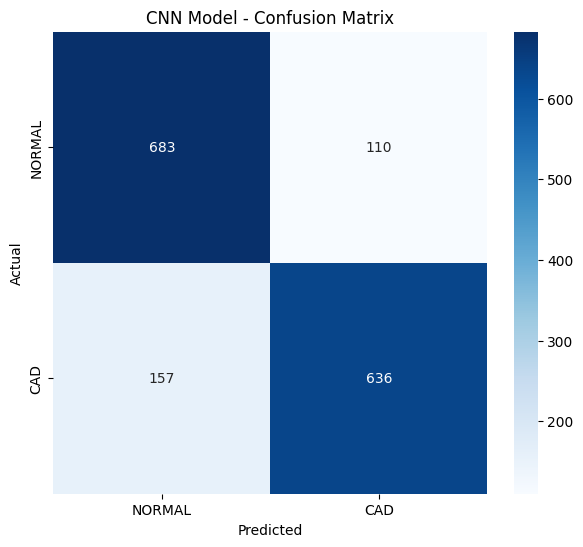

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load best weights
model.load_weights(ckpt_path)
print("Loaded best CNN model.")

# CNN Predictions
y_prob = model.predict(X_test)
y_pred = (y_prob >= 0.5).astype(int).reshape(-1)

# --- Accuracy ---
print("\nAccuracy:", accuracy_score(y_test, y_pred))

# --- Classification Report ---
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NORMAL","CAD"],
    yticklabels=["NORMAL","CAD"]
)
plt.title("CNN Model - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("===== PERFORMANCE METRICS (LSTM) =====")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")


===== PERFORMANCE METRICS (LSTM) =====
Accuracy : 0.8317
Precision: 0.8525
Recall   : 0.8020
F1 Score : 0.8265


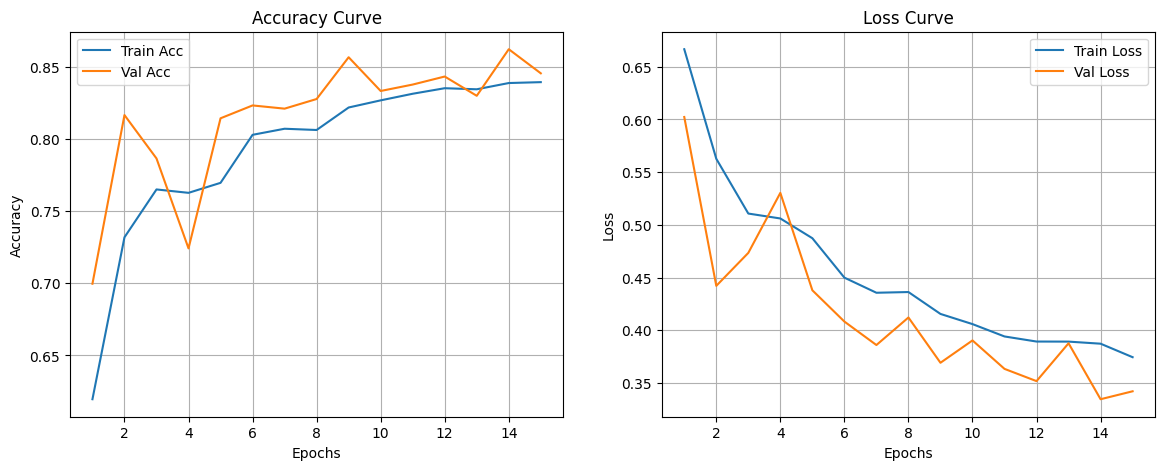

In [17]:
# ==== CELL: Accuracy & Loss Graphs ====
import matplotlib.pyplot as plt

acc      = history.history["accuracy"]
val_acc  = history.history["val_accuracy"]
loss     = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(acc)+1)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(epochs, acc, label="Train Acc")
plt.plot(epochs, val_acc, label="Val Acc")
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.show()


In [12]:
# ==== CELL: Signal formatting ====
from scipy.signal import resample

def format_sig_5000x12(sig):
    sig = np.array(sig, dtype="float32")

    if sig.ndim == 1:
        sig = sig[:, None]

    if sig.shape[0] < sig.shape[1] and sig.shape[0] <= 12:
        sig = sig.T

    if sig.shape[1] < 12:
        sig = np.pad(sig, ((0,0),(0,12-sig.shape[1])), 'constant')
    elif sig.shape[1] > 12:
        sig = sig[:, :12]

    L = sig.shape[0]
    if L != 5000:
        out = np.zeros((5000, 12), dtype="float32")
        for i in range(12):
            out[:, i] = resample(sig[:, i], 5000)
    else:
        out = sig

    # normalize
    for i in range(12):
        m, s = out[:,i].mean(), out[:,i].std()
        if s < 1e-6: out[:,i] = 0
        else:        out[:,i] = (out[:,i] - m) / (s+1e-8)

    return out


In [13]:
import wfdb
import pandas as pd
import os

def load_npy(path):
    return format_sig_5000x12(np.load(path))

def load_csv(path):
    df = pd.read_csv(path)
    return format_sig_5000x12(df.to_numpy())

def load_dat(path):
    if path.endswith(".dat"):
        path = path[:-4]

    rec = wfdb.rdrecord(path)
    return format_sig_5000x12(rec.p_signal)


In [14]:
CLASS = {0: "NORMAL", 1: "CAD"}

def predict_ecg(path):
    ext = os.path.splitext(path)[1].lower()

    if ext == ".dat":
        sig = load_dat(path)
    elif ext == ".npy":
        sig = load_npy(path)
    elif ext == ".csv":
        sig = load_csv(path)
    else:
        raise ValueError("Unsupported file type")

    sig = np.expand_dims(sig, axis=0)

    prob = float(model.predict(sig)[0][0])
    pred = int(prob >= 0.5)

    print("\n========= PREDICTION =========")
    print("File  :", path)
    print("Class :", CLASS[pred])
    print(f"Prob(CAD): {prob:.4f}")
    print(f"Prob(NORMAL): {1-prob:.4f}")

    return pred, prob


In [15]:
predict_ecg("/kaggle/input/ecg-detection/ptbl_xl_large_dataset/cleaned_signals/signal_0.npy")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step

========= PREDICTION =========
File  : /kaggle/input/ecg-detection/ptbl_xl_large_dataset/cleaned_signals/signal_0.npy
Class : CAD
Prob(CAD): 0.9427
Prob(NORMAL): 0.0573


(1, 0.9426587224006653)